# Michael Vazquez<br>Econ 570, Midterm<br>Forecasting Interest Rates and the Impact on Industrial Production<br>Link to code: https://github.com/Vazquez-Michael-V/570_homework/blob/main/midterm/econ_570_midterm.ipynb


# <center><u><b>Forecasting Dataset and Timeframes</b></u></center>
&nbsp;&nbsp;&nbsp;&nbsp;The provided dataset is 10 year U.S. Treasury Bond interest rates at business end of week, ie Friday, frequency sampled from January 2000 to December 2025. Forecasts will be made of the 10 year U.S. Treasury Bond interest rate using five models. For all models, the training timeframe is from January 2000 to December 2010, and the holdout timeframe is from January 2011 to December 2025. More concisely:


**Full timeframe of the dataset:**
2000-01-07 - 2025-12-26, T = 1,356 end of business week observations.

**Training timeframe:**
2000-01-07 - 2010-12-31, R = 574 end of business week observations.

**Holdout timeframe:**
2011-01-07 - 2025-12-26, P = 782 forecasts to be made.

**Note 1:** End of business week in the context of this analysis is Friday. No information was provided concerning observations on which a given Friday is a holiday.

**Note 2:** The values of T, R, and P are further explained in Question 1.1.


<h1><center><u><b>Models</b></u></center></h1>
&nbsp;&nbsp;&nbsp;&nbsp;We are given five naive forecasting models to analyze the 10 year U.S. Treasury Bond interest rate at a forecast horizon of h = 1 week ahead.

**General Form of Simple Mean Models:**
$$\hat{y}_{t+1|t} = \frac{1}{S}\sum_{i=t-S+1}^{t} y_i$$

**Model 1A, Simple Mean with $S=1$:**
$$\hat{y}_{t+1|t} = y_t$$

**Model 1B, Simple Mean with $S=4$:**
$$\hat{y}_{t+1|t} = \frac{1}{4}\sum_{i=t-3}^{t} y_i$$

**Model 1C, Simple Mean with $S=52$:**
$$\hat{y}_{t+1|t} = \frac{1}{52}\sum_{i=t-51}^{t} y_i$$

**Model 2, Random Walk with Drift (RWD):**
$$y_t = \alpha + y_{t-1} + \varepsilon_t$$

**Model 3, Random Walk (RW):**
$$y_t = y_{t-1} + \varepsilon_t$$





# Imports.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import warnings
# Suppress ARIMA convergence warnings, as we will only use ARIMA for
# validating the random walk models. 
warnings.filterwarnings('ignore', category=ConvergenceWarning)

import seaborn as sns

import sympy as sp

import os

from IPython.display import display, Math, Image


plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    # This font neatly displays Greek letters in plots.
    'mathtext.fontset': 'cm',
    'axes.grid': True,
    'grid.alpha': 0.35
    # 'axes.spines.top': False,
    # 'axes.spines.right': False
})



# Module that I made for summary statistics of interest to Econ 570.
# More functions may be added later in the course.
from econ_570_mod.summary_statistics import summary_statistics



# Notebook variables.

In [2]:
# These dates will be used throughout the notebook.
TRAIN_START = '2000-01-07'
TRAIN_END = '2010-12-31'
HOLD_START = '2011-01-07'
HOLD_END = '2025-12-26'

# Setup model labels and colors to keep consistent color theme throughout
# the notebook.
MODEL_LABELS = ['Model 1A (S=1)', 'Model 1B (S=4)', 'Model 1C (S=52)', 'Model 2 (RWD)', 'Model 3 (RW)']
MODEL_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
# Forecast.
FC_COLS = ['fc_1a', 'fc_1b', 'fc_1c', 'fc_2', 'fc_3']
# Errors.
ERR_COLS = ['e_1a',  'e_1b',  'e_1c',  'e_2',  'e_3']




# Read and clean the 10 year U.S. Treasury Bond Interest Rate data.

In [3]:
# ir for interest rate.
df_ir = pd.read_excel(
    r'Midterm 10-Year Bond Rate - Interest Rate Data.xlsx',
    sheet_name='Weekly, Ending Friday'
).rename(
    columns={
        'observation_date': 'date',
        'WGS10YR': 'rate'
    },
    errors='raise'
).astype(
    {
        'date': 'datetime64[ns]',
        'rate': 'float64'
    }
).sort_values(
    by=['date']
).reset_index(drop=True)

# As discussed in the both the notebook intro and the README tab of the excel
# file, all dates should be Fridays.
assert df_ir['date'].dt.day_name().drop_duplicates().to_list() == ['Friday'],\
    "At least one date in the dataset is not a Friday."

# Nulls in the 'date' or 'rate' column would causes forecasting issues.
for col in df_ir:
    assert not df_ir[col].hasnans, f"Column '{col}' has at least one nan value."

# Ensure df_ir is the full timeframe specified in the midterm.
df_ir = df_ir.loc[(df_ir['date'].between(TRAIN_START, HOLD_END, inclusive='both')), :].reset_index(drop=True)

# Check that the data is actually weekly. In other words, check that there is a time 
# difference of 7 days between each observation. Note that df_ir has
# already been ordered by date ASC.
ser_week_check = df_ir.loc[:, 'date']\
    .copy()\
    .diff()\
    .dt.days\
    .dropna()

assert ser_week_check.loc[ser_week_check != 7].empty,\
    "Differencing observations, found a difference not equal to 7."

print("df_ir['date'] describe:")
display(df_ir['date'].describe())
# Set date as index to ensure reliable .shift() and .rolling() on time series.
df_ir = df_ir.set_index('date')

ser_num_fridays = df_ir.index.year.to_series().value_counts(dropna=False).sort_index()
print("Years with more than 52 Fridays:")
display(ser_num_fridays.loc[ser_num_fridays > 52])
# There are 52 weeks in a year, but depending on year start day and leap year there can
# be 53 Fridays in a year.
assert ser_num_fridays.loc[ser_num_fridays > 53].empty,\
    "There is at least one year with more than 53 Fridays."

print("df_ir info:")
print(df_ir.info(show_counts=True, verbose=True))
print(f"df_ir shape: {df_ir.shape}")
print("df_ir sample:")
display(df_ir.sample(n=10))


df_ir['date'] describe:


count                   1356
mean     2012-12-31 12:00:00
min      2000-01-07 00:00:00
25%      2006-07-05 06:00:00
50%      2012-12-31 12:00:00
75%      2019-06-29 18:00:00
max      2025-12-26 00:00:00
Name: date, dtype: object

Years with more than 52 Fridays:


date
2004    53
2010    53
2016    53
2021    53
Name: count, dtype: int64

df_ir info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1356 entries, 2000-01-07 to 2025-12-26
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rate    1356 non-null   float64
dtypes: float64(1)
memory usage: 21.2 KB
None
df_ir shape: (1356, 1)
df_ir sample:


,rate
date,
2006-08-18,4.90
2010-12-10,3.18
2021-03-19,1.66
2009-11-27,3.30
2010-12-03,2.93
2002-05-31,5.10
2019-01-18,2.74
2009-07-03,3.53
2013-01-04,1.87


# Question 1.1 - Values of T, R, and P.

In [4]:
# The data has already been cleaned, so the values of T, R, and P here are accurate.
T = df_ir.shape[0]
R = df_ir.loc[TRAIN_START:TRAIN_END, :].shape[0]
P = df_ir.loc[HOLD_START:HOLD_END, :].shape[0]

assert T == R + P, f"The sum of R and P should be {T} but is {R + P}."

print(f"T = {T}, the total number of observations over the entire timeframe of the sample interest rate data.")
print(f"R = {R}, the number of observations over the training timeframe.")
print(f"P = {P}, the number of forecasts to be made over the holdout timeframe.")

# Place T, R, and P info into a DataFrame for an easy tabular display.
df_trp = pd.DataFrame(data={
    'variable': ['T', 'R', 'P'],
    'value': [T, R, P],
    'start_date': [
        df_ir.index.min().strftime('%Y-%m-%d'),
        TRAIN_START,
        HOLD_START
    ],
    'end_date': [
        df_ir.index.max().strftime('%Y-%m-%d'),
        TRAIN_END,
        HOLD_END
    ]
})
display(df_trp)

T = 1356, the total number of observations over the entire timeframe of the sample interest rate data.
R = 574, the number of observations over the training timeframe.
P = 782, the number of forecasts to be made over the holdout timeframe.


,variable,value,start_date,end_date
0,T,1356,2000-01-07,2025-12-26
1,R,574,2000-01-07,2010-12-31
2,P,782,2011-01-07,2025-12-26


#### Discussion on the values of T, R, and P.
&nbsp;&nbsp;&nbsp;&nbsp;Per "Lecture 7.pdf" slide 15, the total number of observations over the entire timeframe of the sample dataset is T = R + P, where R is the number of observations in the the training timeframe and P is the number of out of sample forecasts created over the holdout timeframe.

# Question 1.2 - Plot the weekly data.

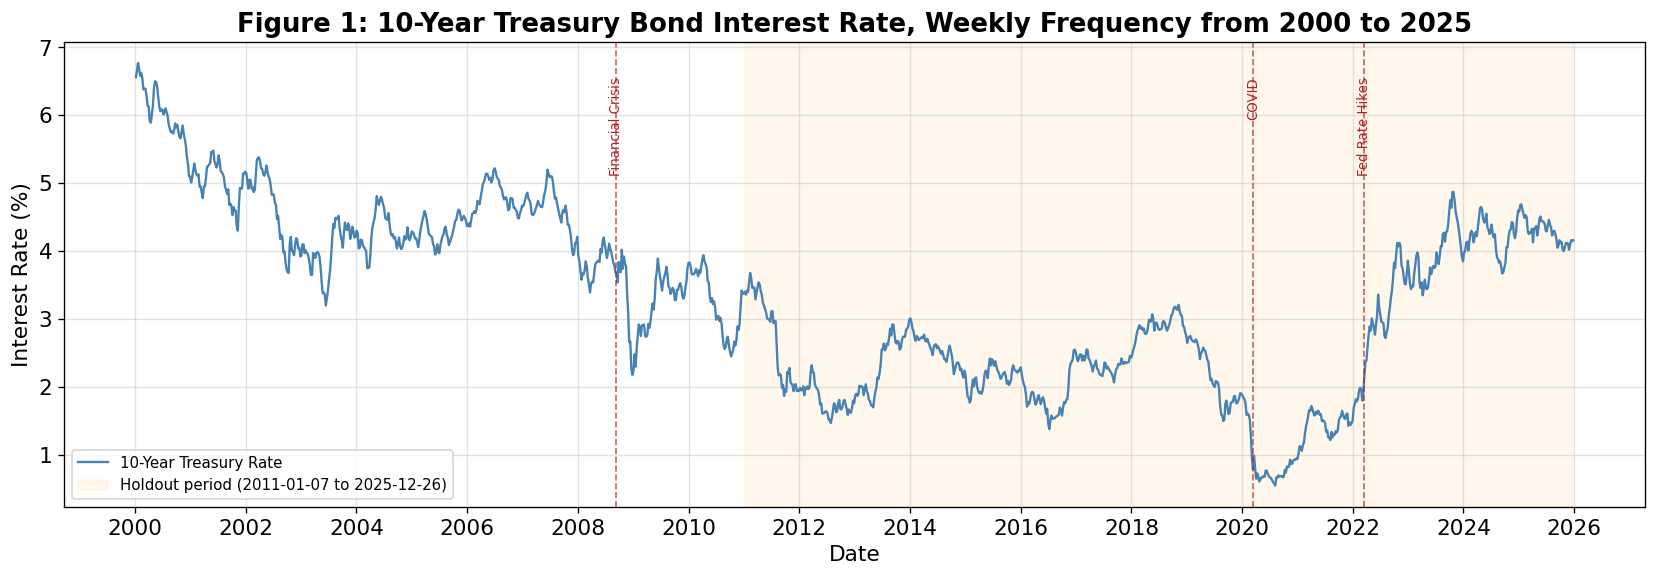

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_ir.index, df_ir['rate'], color='steelblue', lw=1.4, label='10-Year Treasury Rate')

# Shade the holdout period.
ax.axvspan(pd.Timestamp(HOLD_START), pd.Timestamp(HOLD_END),
           alpha=0.08, color='orange', label=f'Holdout period ({HOLD_START} to {HOLD_END})')

# Annotate economic events that strongly impacted the federal funds rate.
events = [
    ('2008-09-12', 'Financial Crisis'),
    ('2020-03-13', 'COVID'),
    ('2022-03-18', 'Fed Rate Hikes'),
]
for date_str, label in events:
    ts = pd.Timestamp(date_str)
    ax.axvline(ts, color='firebrick', lw=1.0, ls='--', alpha=0.7)
    ax.text(ts, df_ir['rate'].max() * 0.97, label,
            fontsize=8, color='firebrick', ha='center', va='top', rotation=90)

ax.set_title('Figure 1: 10-Year Treasury Bond Interest Rate, Weekly Frequency from 2000 to 2025',
             fontweight='bold')
ax.set_ylabel('Interest Rate (%)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

#### Discussion on Figure 1

&nbsp;&nbsp;&nbsp;&nbsp;The federal funds rate and the 10-year U.S. Treasury Bond interest rate typically move in the same direction, ie have a positive relationship. When the Fed raises the funds rate, markets update their expectations for future short term rates and the 10-year interest rate rises with it. However, during periods of economic crisis this relationship may not hold as investors seek stability in 
U.S. Treasury Bonds, driving bond prices up and interest rates down regardless of Fed policy.

&nbsp;&nbsp;&nbsp;&nbsp; From 2000 to 2008 the interest rate had an overall downward trend before the Financial Crisis triggered a sharp drop caused by investors seeking reliable returns in bonds. As the economy slowly recovered, the Fed held the funds rate near zero for years, keeping the 10-year interest rate low, encouraging investment in financial assets outside of the bonds market. In 2015, the Fed began cautiously raising the funds rate. The 10-year interest rate increased, demonstrating the typical positive relationship between the funds rate and bond interest rates.

&nbsp;&nbsp;&nbsp;&nbsp;COVID in 2020 caused a sharp interest rate decrease as the Fed cut rates to near zero again. As seen in previous assignments, the economy recovered from the COVID crisis far faster than from the 2008 Financial Crisis, which led the Fed to quickly raise interest rates throughout 2022. The rapid increase in 10-year interest rates from 1% in 2020 to nearly 4% in 2022 will be a challenge for all five forecasting models, as there is no such rapid increase in the training period.


In [6]:
ir_summary_stats_dict = summary_statistics(
    df_ir,
    'rate',
    'date'
)
display(ir_summary_stats_dict)

{'df_summary_stats':   statistic   value
 0      mean  3.3220
 1    median  3.4250
 2       var  1.6747
 3   std_dev  1.2941
 4  skewness  0.0484
 5  kurtosis -0.7331,
 'min_date': Timestamp('2000-01-07 00:00:00'),
 'max_date': Timestamp('2025-12-26 00:00:00')}

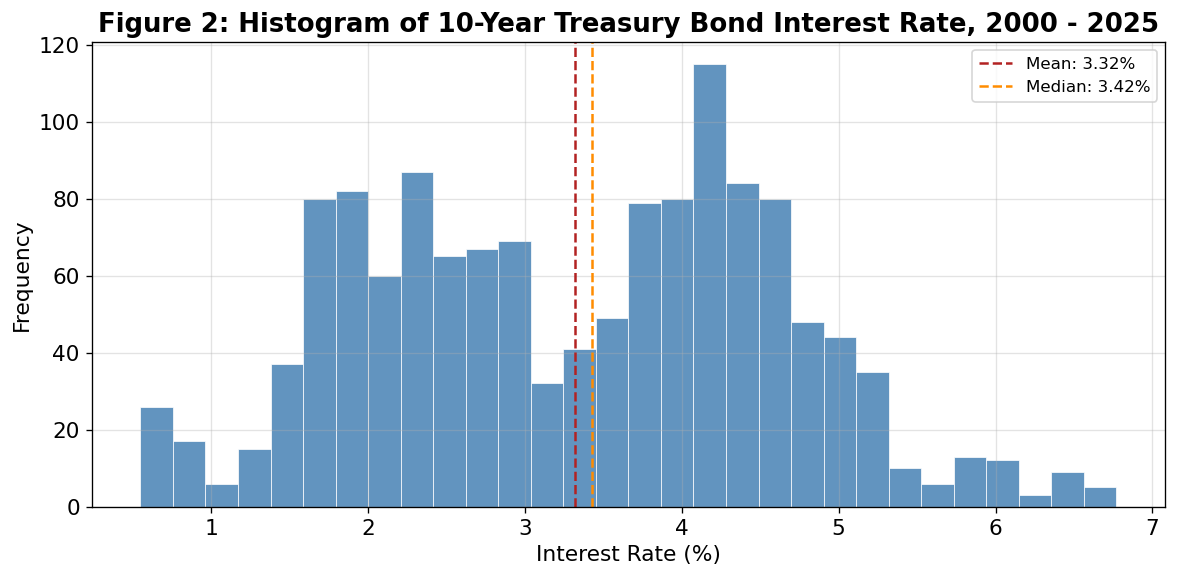

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df_ir['rate'],
    bins=30,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85
)

ax.axvline(
    df_ir['rate'].mean(),
    color='firebrick',
    lw=1.5,
    ls='--',
    label=f"Mean: {df_ir['rate'].mean():.2f}%"
)
ax.axvline(
    df_ir['rate'].median(),
    color='darkorange',
    lw=1.5,
    ls='--',
    label=f"Median: {df_ir['rate'].median():.2f}%"
)

ax.set_title('Figure 2: Histogram of 10-Year Treasury Bond Interest Rate, 2000 - 2025',
             fontweight='bold')
ax.set_xlabel('Interest Rate (%)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

#### Discussion on Figure 2 and Summary Statistics

&nbsp;&nbsp;&nbsp;&nbsp;Let's consider the summary statistics of 10-year interest rates across the entire sample timeframe and how they relate to Figure 1. A nearly zero skew of 0.0484 and the bimodal shape of the histogram suggests 2 intervals for interest rates (0%, 3%] and 
(3%, 7%). In Figure 1, interest rate from 1% to 3% is typical in the years from 2008 to 2022, while interest rate from 4% to 6% is typical outside of those years.

&nbsp;&nbsp;&nbsp;&nbsp;Standard deviation in economic terms here can be thought of as volatility in the 10-year U.S. Treasury Bond interest rate. A standard deviation of 1.29, with all observed interest rates in the sample between 0% and 7%, represents notable volatility in the sample.

&nbsp;&nbsp;&nbsp;&nbsp;The mean 3.32% less than the median 3.42% suggests that the mean is pulled down by periods of economic crisis. The negative excess kurtosis of -0.7331 indicates flatter tails in the distribution, ie not many extreme observations.


# Question 1.3 - Create forecasts.

#### Discussion on models and code implementation.

&nbsp;&nbsp;&nbsp;&nbsp;